# <center> **Домашнее задание №3** </center>

*Фамилия Имя:*

## **Задача 1. Генератор** **(15 баллов)**

#### **Задание**

Напишите **генератор**, который принимает коллекцию с вложенными итерируемыми объектами, а возвращает каждый элемент последовательно.

**Примеры работы генератора**


```python
[[1, 2, 3], [4, [5, 6, [7, 8]]]] → [1, 2, 3, 4, 5, 6, 7, 8]
```

```python
[1, 2, 'abc', [2, 4], {'key': 'value'}] → [1, 2, 'a', 'b', 'c', 2, 4, 'k', 'e', 'y']
```

*Обратите внимание: итерация по словарям происходит **по ключам**.*


**Подсказка**

Для проверки, что объект является итерируемым, используйте:

```python
from collections.abc import Iterable

# В вашем коде:
assert isinstance(x, Iterable), 'Объект не итерируемый'
```

Функция `isinstance(x, tp)` проверяет, относится ли объект `x` к типу `tp`.

*Не забудьте обработать строки особым образом, так как они тоже являются итерируемыми объектами!*

In [9]:
from collections.abc import Iterable

def generator(collection):
    for i in collection:
        if isinstance(i, Iterable):
            if isinstance(i, str):
                for j in i:
                    yield j
            elif isinstance(i, dict):
                for key in i:
                    for k in key:
                        yield k
            else:
                yield from generator(i)
        else:
            yield i
print("Пример 1:")
collection1 = [[1, 2, 3], [4, [5, 6, [7, 8]]]]
result1 = list(generator(collection1))
print(f"Вход: {collection1}")
print(f"Выход: {result1}")

print("Пример 2:")
collection2 = [1, 2, 'abc', [2, 4], {'key': 'value'}]
result2 = list(generator(collection2))
print(f"Вход: {collection2}")
print(f"Выход: {result2}")


Пример 1:
Вход: [[1, 2, 3], [4, [5, 6, [7, 8]]]]
Выход: [1, 2, 3, 4, 5, 6, 7, 8]
Пример 2:
Вход: [1, 2, 'abc', [2, 4], {'key': 'value'}]
Выход: [1, 2, 'a', 'b', 'c', 2, 4, 'k', 'e', 'y']


## **Задача 2. itertools** **(15 баллов)**

#### **О модуле itertools**

Модуль `itertools` представляет множество инструментов для работы с итераторами.

Официальная документация: https://docs.python.org/3/library/itertools.html

#### **Задание**

**Входные данные:**
1. Числа вводятся **через пробел** в одной строке
2. Затем вводится число **`n`**

**Задача:** Напишите программу, которая находит все **уникальные пары чисел** из списка, где сумма каждой пары равна числу `n`.

*Можете использовать модуль `itertools` для решения!*

#### **Пример работы**

**Вход:**
```
1 2 3 4 5 6
7
```

**Выход:**
```python
[(1, 6), (2, 5), (3, 4)]
```

*Программа выводит пары чисел, которые в сумме дают 7.*

**Важные условия**

- Гарантируется, что числа во входной последовательности не повторяются
- Пары в кортежах должны быть в том же порядке, что и в исходном списке
  - Например: `(1, 6)` — правильно, `(6, 1)` — неправильно (если 1 идёт раньше 6 в списке)
- Пара числа с самим собой не подходят 

In [20]:
import itertools
numbers = list(map(int, input("Введите числа через пробел").split()))
n = int(input("Введите число n: "))
result = set()
for para in itertools.combinations(numbers, 2):
    if para[0] + para[1] == n:
        result.add(para)
rusult = tuple(sorted(result))
print(result)
               

Введите числа через пробел 0 3 1 4 2 2
Введите число n:  4


{(3, 1), (0, 4), (2, 2)}


**Задание 2.1 (2.5 балла)**

Вводятся числа в одной строке через пробел.

Например, '4 2 5 2 5 1'

Необходимо найти наименьшее нечетное число. Например, для примера выше это 1.

Решение должно занимать ровно одну строку любой длины.

Запрещено использовать циклы, условные операторы и list comprehension.


In [26]:
print (min(filter(lambda x: x%2==1, map(int, input().split()))))

 8 10 15 18 7


7


**Задание 2.2 (2.5 балла)**

Вводится одно число n.

Используя модуль `itertools`, выведите в одной строке через запятую и пробел факториалы чисел от 0 до n.

Запрещено использовать циклы, условные операторы и list comprehension.

Например, для n = 7 на экран надо вывести:

1, 1, 2, 6, 24, 120, 720, 5040

In [48]:
import math
print(*itertools.starmap(math.factorial, zip(range(int(input())+1))), sep = ", ")


 8


1, 1, 2, 6, 24, 120, 720, 5040, 40320


### **Задача 3. Numpy (22 балла)**

#### 3.1 **Вспоминаем, что такое numpy**

Создайте с помощью `np.random.randint` numpy массив из 20-ти рандомных чисел. **(0.5 балла)**

Посчитайте с помощью методов `numpy` и выведите на экран:

- среднее значение в массиве **(0.5 балла)**
- минимальное значение в массиве **(0.5 балла)**
- максимальное значение в массиве **(0.5 балла)**
- индекс минимального элемента в массиве **(0.5 балла)**

In [50]:
import numpy as np
import time # понадобится для замера времени в следующих пунктах

In [59]:
arr = np.random.randint(0, 100, 20)
print("Массив из 20-ти рандомных чисел", arr )
print("Среднее значение в массиве", np.mean(arr))
print("Минимальное значение в массиве", np.min(arr))
print("Максимальное значение в массиве", np.max(arr))
print("Индекс минимального элемента в массиве", np.argmin(arr))

Массив из 20-ти рандомных чисел [15 93 36 74  1 85  9 75 44 29  9 82 84 75 27 82 78 87 10 10]
Среднее значение в массиве 50.25
Минимальное значение в массиве 1
Максимальное значение в массиве 93
Индекс минимального элемента в массиве 4


Создайте два numpy массива: в первом должны быть четные числа от 2 до 14 включительно, а во втором — числа 7, 11, 17, 18, 23, 30, 45.

- Сложите массивы и возведите элементы получившегося массива в квадрат
- Выведите все элементы из первого массива, которые стоят на тех местах, где элементы второго массива больше 12 и дают остаток 3 при делении на 5.
- Для первого массива найдите остатки от деления на 2, а для второго — на 3.

**Общий балл: 1.5 балла**

In [71]:
arr1 = np.array(range(2, 15, 2))
arr2 = np.array([7, 11, 17, 18, 23, 30, 45])
print("Первый массив", arr1)
print("Второй массив", arr2)
sum_arr_sq=(arr1+arr2)**2
print("Сумма массивов в квадрате:", sum_arr_sq)
task2_arr=(arr2>12) & (arr2%5==3)
elements1 = arr1[task2_arr]
print("Все элементы из первого массива, которые стоят на тех местах, где элементы второго массива больше 12 и дают остаток 3 при делении на 5", elements1)
remainder1=arr1%2
remainder2=arr2%3
print("Остатки первого массива при делении на 2:", remainder1)
print("Остатки второго массива при делении на 3:", remainder2)

Первый массив [ 2  4  6  8 10 12 14]
Второй массив [ 7 11 17 18 23 30 45]
Сумма массивов в квадрате: [  81  225  529  676 1089 1764 3481]
Все элементы из первого массива, которые стоят на тех местах, где элементы второго массива больше 12 и дают остаток 3 при делении на 5 [ 8 10]
Остатки первого массива при делении на 2: [0 0 0 0 0 0 0]
Остатки второго массива при делении на 3: [1 2 2 0 2 0 0]


1. Сгенерируйте рандомный массив b размера 3x1.
2. Сгенерируйте матрицу С размера 3x3.
3. Решите систему Cx = b с помощью `numpy.linalg.solve`
4. Подумайте/погуглите, в каком случае `numpy.linalg.solve` вернет ошибку LinAlgError. Воспроизведите этот случай.

**Общий балл: 2 балла**

In [84]:
b=np.random.rand(3, 1)
print("Массив b")
print(b)
C=np.random.rand(3, 3)
print("Матрица С")
print(C)
try:
    x = np.linalg.solve(C, b)
    print("Решение системы Cx = b:")
    print(x)
except np.linalg.LinAlgError as e:
    print("Ошибка при решении:")
    print(e)

# Примеры, когда вернется ошибка
A = np.array([[1, 2], [2, 4]])  # так как определитель матрицы равен 0
B = np.array([[1, 2, 3], [4, 5, 6]])  # так как матрица не квадратная

Массив b
[[0.84217172]
 [0.72554676]
 [0.02239952]]
Матрица С
[[0.20871763 0.38633302 0.67645147]
 [0.77384043 0.06233903 0.1737043 ]
 [0.76720638 0.06504701 0.99636746]]
Решение системы Cx = b:
[[ 0.87150637]
 [ 3.21186063]
 [-0.85826534]]


#### **3.2 Сравнение производительности**

Сравните производительность операций умножения матриц с использованием библиотеки NumPy и стандартных списков Python для матриц размером от 2x2 до 100x100.

1. Сгенерируйте две матрицы A и B случайного размера nxn, заполненные случайными целыми числами от 1 до 50. **(1 балл)**
2. Используя библиотеку NumPy, выполните умножение матриц A и B. Измерьте время выполнения операции. **(2 балла)**
3. Реализуйте функцию для умножения матриц с помощью стандартных списков Python. Измерьте время выполнения этой операции. **(3 балла)**
4. Сделайте вышеперечисленные пункты для n=2,...100. **(4 балла)**
5. Для какого-нибудь n проверьте, совпадают ли результаты. **(1 балл)**
7. Для каждого n выведите на экран размеры матриц и время выполнения умножения для обеих реализаций. **(2.5 баллов)**
8. Постройте график, где по оси X будет размер матрицы, по оси Y - время выполнения операции. Постройте два графика (для numpy и для стандартных списков) **(2.5 баллов)**

Сравнение производительности умножения матриц
n	Время NumPy (сек)	Время Python (сек)
2	0.000015		0.000315
3	0.000009		0.000024
4	0.000007		0.000043
5	0.000006		0.000076
6	0.000007		0.000122
7	0.000007		0.000184
8	0.000010		0.000252
9	0.000009		0.000318
10	0.000011		0.000386
11	0.000012		0.000548
12	0.000016		0.000723
13	0.000017		0.000900
14	0.000014		0.000807
15	0.000012		0.000588
16	0.000010		0.001198
17	0.000013		0.001417
18	0.000017		0.000877
19	0.000010		0.001787
20	0.000013		0.001273
21	0.000015		0.002045
22	0.000034		0.006676
23	0.000039		0.004403
24	0.000036		0.008198
25	0.000032		0.004322
26	0.000018		0.008711
27	0.000036		0.004305
28	0.000027		0.007357
29	0.000029		0.002634
30	0.000028		0.008563
31	0.000034		0.008423
32	0.000103		0.008964
33	0.000034		0.008330
34	0.000036		0.006874
35	0.000068		0.006475
36	0.000040		0.004761
37	0.000034		0.005203
38	0.000040		0.014966
39	0.000042		0.006052
40	0.000042		0.010844
41	0.000048		0.015193
42	0.000061		0.020720
43	0.000099		0.022551

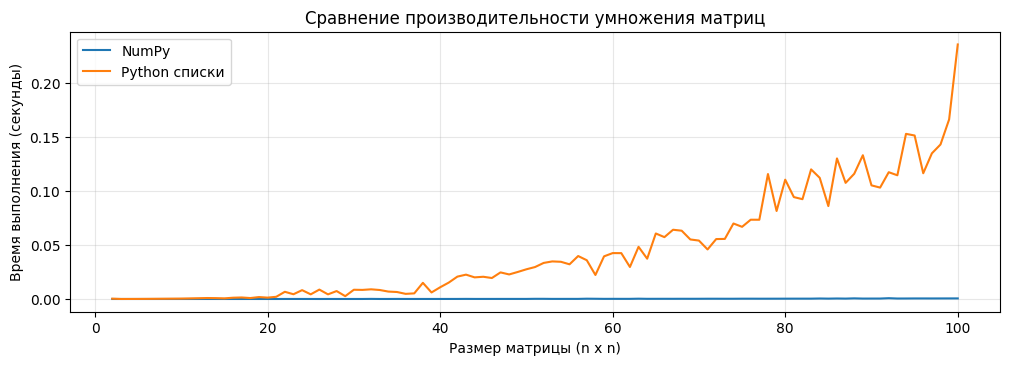

In [104]:
import matplotlib.pyplot as plt
import random
def matrix_multiply_python(A, B):
    n = len(A)
    C = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

def generate_random_matrix(n):
    return [[random.randint(1, 50) for _ in range(n)] for _ in range(n)]
sizes = []
times_numpy = []
times_python = []

print("Сравнение производительности умножения матриц")
print("n\tВремя NumPy (сек)\tВремя Python (сек)")

for n in range(2, 101):
    sizes.append(n)
    A_list = generate_random_matrix(n)
    B_list = generate_random_matrix(n)
    A_np = np.array(A_list)
    B_np = np.array(B_list)
    
    start_time = time.time()
    C_np = np.dot(A_np, B_np)
    numpy_time = time.time() - start_time
    times_numpy.append(numpy_time)
    
    start_time = time.time()
    C_python = matrix_multiply_python(A_list, B_list)
    python_time = time.time() - start_time
    times_python.append(python_time)
    
    print(f"{n}\t{numpy_time:.6f}\t\t{python_time:.6f}")

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(sizes, times_numpy, label='NumPy')
plt.plot(sizes, times_python, label='Python списки')
plt.xlabel('Размер матрицы (n x n)')
plt.ylabel('Время выполнения (секунды)')
plt.title('Сравнение производительности умножения матриц')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **Задача 4. Введение в pandas (8 баллов)**

Работаем с датасетом по кредитному скорингу `loan_data.csv`. Скачайте его здесь https://disk.yandex.ru/d/xkujsz3HFJ8taw и считайте с помощью `pd.read_csv`.

#### **Используемые столбцы:**

- `credit.policy` - 1, если клиент соответствует критериям выдачи кредита, 0 в противном случае.
- `purpose` - цель кредита (принимает значения "credit_card", "debt_consolidation", "educational", "home_improvement", "major_purchase", "small_business" и "all_other").
- `int.rate` - процентная ставка по кредиту.
- `installment` - ежемесячный платеж, причитающийся заемщику в случае финансирования кредита.
- `log.annual.inc` - натуральный логарифм годового дохода заемщика, представленного им самим.
- `dti` - отношение долга к доходу заемщика (сумма долга, деленная на годовой доход).
- `fico` - кредитный рейтинг FICO заемщика.
- `days.with.cr.line` - количество дней, в течение которых у заемщика была открыта кредитная линия.
- `revol.bal` - возобновляемый баланс заемщика (сумма, не выплаченная в конце платежного цикла по кредитной карте).
- `revol.util` - коэффициент использования возобновляемой кредитной линии заемщиком (сумма использованной кредитной линии по отношению к общему объему доступных кредитов).
- `inq.last.6mths` - количество запросов заемщика от кредиторов за последние 6 месяцев.
- `delinq.2yrs` - количество раз, когда заемщик просрочивал платеж более чем на 30 дней за последние 2 года.
- `pub.rec` - количество негативных публичных записей о заемщике (заявления о банкротстве, налоговые залоги или судебные решения).
- `not.fully.paid` - неполностью выплаченный кредит ранее.

#### **Задания**

**Каждый пункт весит 0.6 балла, но не более 8 баллов за задание.**

1. Выведите первые 5 строк датасета.
2. Сколько в датасете строк и столбцов?
3. Есть ли в датасете пропуски? В каких столбцах сколько пропусков, если есть?
4. Выведите все описательные статистики по числовым столбцам единым методом.
5. Какая средняя процентная ставка по кредиту?
6. Сколько клиентов соответствует условиям выдачи кредита?
7. Как отличается средний логарифм годового дохода заемщиков, которые соответствуют условиям выдачи кредита и тех, кто не соответствует?
8. Какой медианный ежемесячный платеж?
9. Сколько уникальных значений у переменной `not.fully.paid`?
10. Сделайте столбец `annual.inc` для подсчета годового дохода (выполните обратное преобразование столбца `log.annual.inc`)
11. Сделайте группировку по двум переменным: `credit.policy` и `not.fully.paid`. Посчитайте для каждой группы количество клиентов, средний ежемесячный платеж, медианный ежемесячный платеж, средний годовой доход.
12. Выведите топ-10 клиентов по уровню дохода среди тех, кто не удовлетворяет критериям выдачи кредита.
13. Есть ли выбросы у переменной `annual.inc`? Выбросами считайте наблюдения, которые не лежат в границах `[Q1−1.5IQR,Q3+1.5IQR]`, где IQR - межквартильный размах, Q1 - 25 перцентиль, Q3 - 75 перцентиль.
14. Постройте распределения переменных `annual.inc` и `log.annual.inc`

Первые пять строк:


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Количество строк  9578 Количество столбцов 14
Пропуски в данных:
Series([], dtype: int64)
Пропусков нет
Описательные статистики по числовым столбцам:
       credit.policy     int.rate  installment  log.annual.inc          dti  \
count    9578.000000  9578.000000  9578.000000     9578.000000  9578.000000   
mean        0.804970     0.122640   319.089413       10.932117    12.606679   
std         0.396245     0.026847   207.071301        0.614813     6.883970   
min         0.000000     0.060000    15.670000        7.547502     0.000000   
25%         1.000000     0.103900   163.770000       10.558414     7.212500   
50%         1.000000     0.122100   268.950000       10.928884    12.665000   
75%         1.000000     0.140700   432.762500       11.291293    17.950000   
max         1.000000     0.216400   940.140000       14.528354    29.960000   

              fico  days.with.cr.line     revol.bal   revol.util  \
count  9578.000000        9578.000000  9.578000e+03  9578.000000   
me

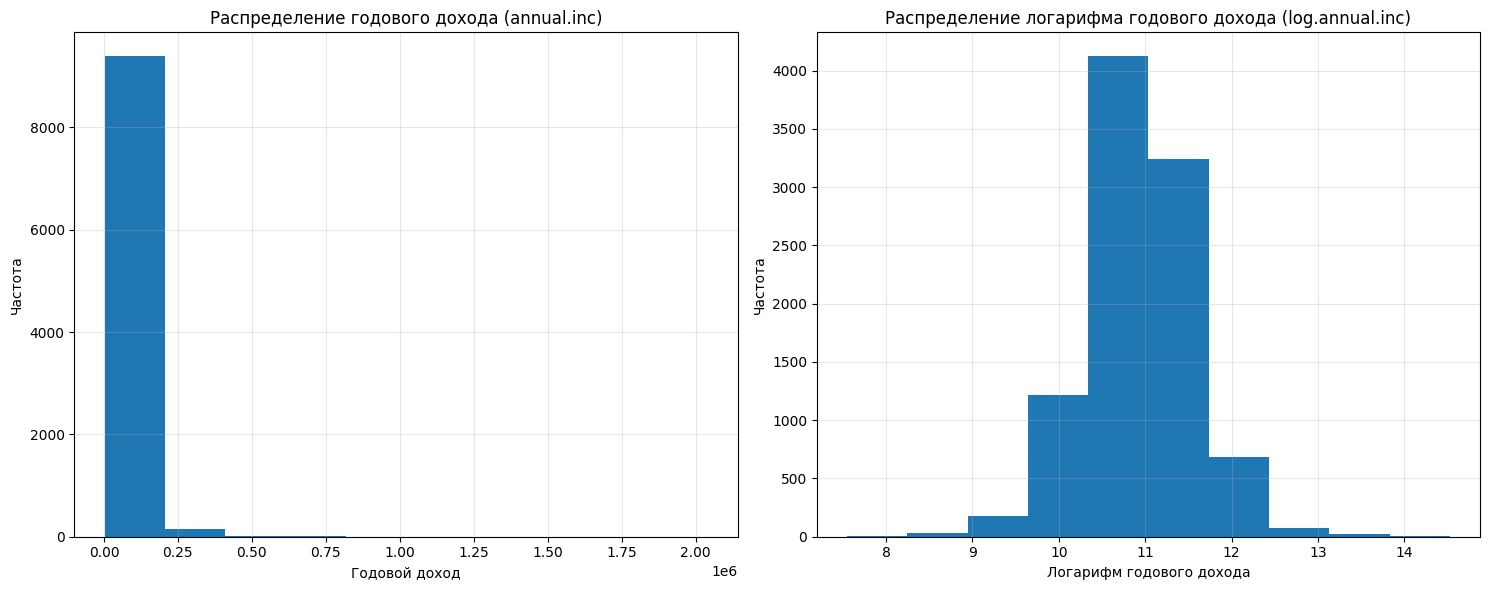

In [128]:
import pandas as pd
data = pd.read_csv('loan_data.csv')

print("Первые пять строк:")
display(data.head (5))

print("Количество строк ", data.shape[0], "Количество столбцов", data.shape[1])

print("Пропуски в данных:")
missing_data = data.isnull().sum()
print(missing_data[missing_data > 0])
if missing_data.sum() == 0:
    print("Пропусков нет")

print("Описательные статистики по числовым столбцам:")
print(data.describe())

avg_interest_rate = data["int.rate"].mean()
print("Средняя процентная ставка по кредиту", avg_interest_rate)

credit_policy_count = data["credit.policy"].value_counts()
print("Клиенты по условиям выдачи кредита:", credit_policy_count)

median_installment = data["installment"].median()
print("Медианный ежемесячный платеж:", median_installment)

unique_not_fully_paid = data["not.fully.paid"].nunique()
print("Уникальных значений в not.fully.paid:", unique_not_fully_paid)

data["annual.inc"] = np.exp(data["log.annual.inc"])

Q1 = data['annual.inc'].quantile(0.25)
Q3 = data['annual.inc'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier = data[(data['annual.inc'] < lower) | (data['annual.inc'] > upper)]
print(f"Выбросы в annual.inc: {len(outlier)} наблюдений")

fig, (ann, annlog) = plt.subplots(1, 2, figsize=(15, 6))
ann.hist(data['annual.inc'])
ann.set_title('Распределение годового дохода (annual.inc)')
ann.set_xlabel('Годовой доход')
ann.set_ylabel('Частота')
ann.grid(alpha=0.3)

annlog.hist(data['log.annual.inc'])
annlog.set_title('Распределение логарифма годового дохода (log.annual.inc)')
annlog.set_xlabel('Логарифм годового дохода')
annlog.set_ylabel('Частота')
annlog.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Задача 5. Декоратор. (7 баллов)**

#### **Задание**


Напишите декоратор, который будет выполнять функцию трижды, делая между выполнениями перерыв в 2 секунды. После каждого выполнения декоратор должен выводить на экран аргументы функции и результат работы (возвращаемое значение)